<a href="https://colab.research.google.com/github/Mangesh0309/Neural-Networks/blob/main/RGB_Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Working with RGB Images

1. Load CIFAR 10 Dataset

In [1]:
import keras
from keras.datasets import cifar10

# load the pre shuffled train and test data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


2. Visualize first 24 training images

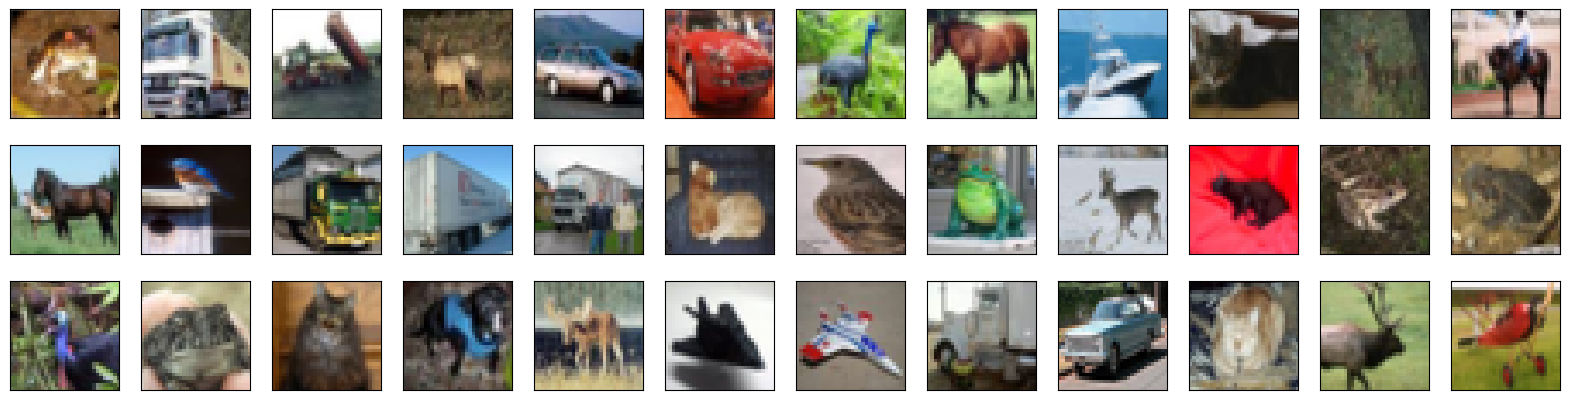

In [4]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

fig = plt.figure(figsize=(20, 5))
for i in range(36):
  ax = fig.add_subplot(3, 12, i+1, xticks=[], yticks=[])
  ax.imshow(np.squeeze(x_train[i]))


3. Rescale the images by dividing every pixel in every image by 255

In [5]:
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

4. Break dataset into Train, Test, and Validation sets

In [6]:
import tensorflow as tf
from tensorflow import keras

# One hot encode the labels
num_classes = len(np.unique(y_train))
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

# Break training set into training and validation sets
(x_train, x_valid) = x_train[5000:], x_train[:5000]
(y_train, y_valid) = y_train[5000:], y_train[:5000]

# print shape of training set
print('x_training shape : ', x_train.shape)

# print number of training, validation and test samples
print(x_train.shape[0], 'train samples')
print(x_valid.shape[0], 'validation samples')
print(x_test.shape[0], 'test samples')

x_training shape :  (45000, 32, 32, 3)
45000 train samples
5000 validation samples
10000 test samples


5. Define the model architecture


In [9]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()
model.add(Conv2D(filters=16, kernel_size=3, padding='same', activation='relu',
                 input_shape=(32, 32, 3)))
model.add(MaxPooling2D(pool_size=2))
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(500, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(10, activation='softmax'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │       512,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 541,094 (2.06 MB)

 Trainable params: 541,094 (2.06 MB)

 Non-trainable params: 0 (0.00 B)

6. Compile the Model

In [12]:
model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

7. Train the Model

In [13]:
from keras.callbacks import ModelCheckpoint

# train the model
checkpointer = ModelCheckpoint(filepath='model.weights.best.keras', verbose=1, save_best_only=True)

hist=model.fit(x_train, y_train, batch_size=32, epochs=10,
               validation_data=(x_valid, y_valid), callbacks=[checkpointer],
               verbose=2, shuffle=True)

Epoch 1/10

Epoch 1: val_loss improved from None to 1.53007, saving model to model.weights.best.keras

Epoch 1: finished saving model to model.weights.best.keras
1407/1407 - 16s - 12ms/step - accuracy: 0.4128 - loss: 1.6178 - val_accuracy: 0.4610 - val_loss: 1.5301
Epoch 2/10

Epoch 2: val_loss improved from 1.53007 to 1.29702, saving model to model.weights.best.keras

Epoch 2: finished saving model to model.weights.best.keras
1407/1407 - 6s - 4ms/step - accuracy: 0.5550 - loss: 1.2561 - val_accuracy: 0.5510 - val_loss: 1.2970
Epoch 3/10

Epoch 3: val_loss improved from 1.29702 to 1.09173, saving model to model.weights.best.keras

Epoch 3: finished saving model to model.weights.best.keras
1407/1407 - 5s - 4ms/step - accuracy: 0.6053 - loss: 1.1262 - val_accuracy: 0.6274 - val_loss: 1.0917
Epoch 4/10

Epoch 4: val_loss improved from 1.09173 to 0.99652, saving model to model.weights.best.keras

Epoch 4: finished saving model to model.weights.best.keras
1407/1407 - 10s - 7ms/step - accura

8. Load the model with the Best Validation Accuracy

In [14]:
model.load_weights('model.weights.best.keras')

9. Visualize some predictions

In [16]:
# get predictions on the test data
y_hat = model.predict(x_test)

# define test labels
cifar10_labels = ['airplane', 'automobile', 'bird', 'cat', 'dear', 'dog', 'frog', 'horse',
                  'ship', 'truck']


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


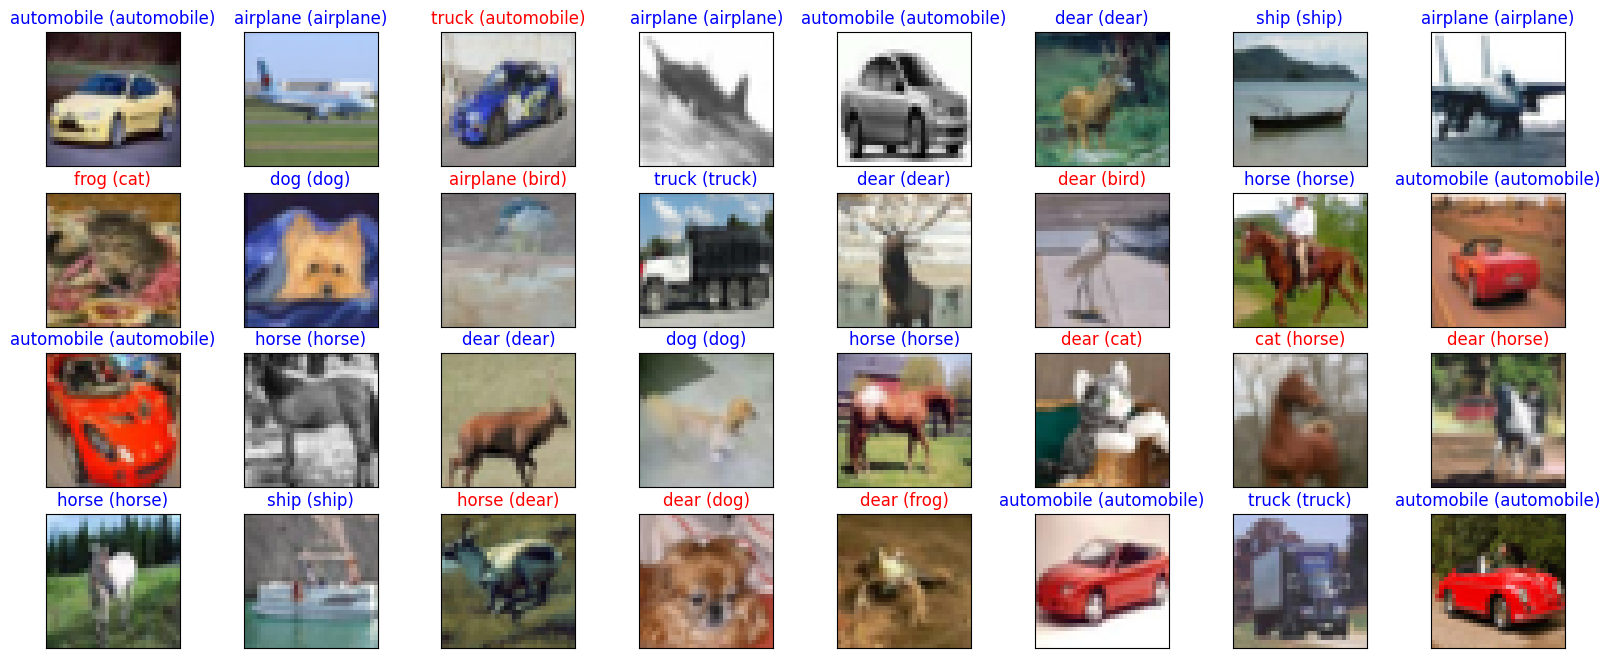

In [18]:
# plot a random sample of test images, their predicted labels, and ground truth
fig = plt.figure(figsize=(20, 8))
for i, idx in enumerate(np.random.choice(x_test.shape[0], size = 32, replace=False)):
  ax = fig.add_subplot(4, 8, i+1, xticks=[], yticks=[])
  ax.imshow(np.squeeze(x_test[idx]))
  pred_idx = np.argmax(y_hat[idx])
  true_idx = np.argmax(y_test[idx])
  ax.set_title("{} ({})".format(cifar10_labels[pred_idx], cifar10_labels[true_idx]),
               color=("blue" if pred_idx ==true_idx else "red"))